## 2.1 理论计算题

### 1. 非线性激活函数的重要性

假设一个具有单隐藏层的多层感知机，输入为 $\mathbf{x}$，隐藏层没有激活函数（即线性激活），表达为 $\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$，输出层为 $\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$。

**推导**：将隐藏层表达式代入输出层：

$$
\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2.
$$

令 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$，则：

$$
\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'.
$$

这是一个没有隐藏层的单层线性网络。因此，若无非线性激活函数，多层线性变换可被合并为单层，无法提升模型表达能力。

---

### 2. 激活函数性质分析

**Sigmoid 函数**：

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

导数推导：

$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))
$$

**Tanh 函数**：

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

导数推导：

$$
\tanh'(x) = 1 - \tanh^2(x)
$$

---

Epoch  1 | Loss: 1.0360 | Test Acc: 0.7604
Epoch  2 | Loss: 0.6002 | Test Acc: 0.7754
Epoch  3 | Loss: 0.5208 | Test Acc: 0.8074
Epoch  4 | Loss: 0.4825 | Test Acc: 0.8175
Epoch  5 | Loss: 0.4543 | Test Acc: 0.8354
Epoch  6 | Loss: 0.4327 | Test Acc: 0.8340
Epoch  7 | Loss: 0.4202 | Test Acc: 0.8343
Epoch  8 | Loss: 0.4056 | Test Acc: 0.8393
Epoch  9 | Loss: 0.3945 | Test Acc: 0.8318
Epoch 10 | Loss: 0.3832 | Test Acc: 0.7837


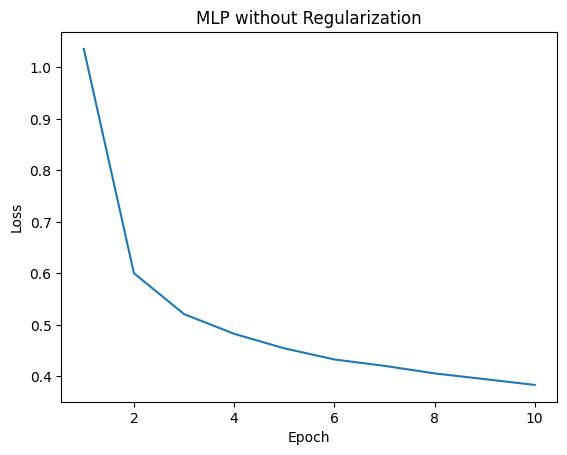

In [ ]:
#2.2 编程题：从零实现单隐藏层MLP（Fashion-MNIST）
import torch
import numpy as np
import gzip
import os
import urllib.request
import matplotlib.pyplot as plt

# 手动加载 Fashion-MNIST 
def download_fashion_mnist():
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    for f in files:
        if not os.path.exists(f):
            print(f"Downloading {f}...")
            urllib.request.urlretrieve(base_url + f, f)

def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

download_fashion_mnist()
X_train = load_mnist_images("train-images-idx3-ubyte.gz")
y_train = load_mnist_labels("train-labels-idx1-ubyte.gz")
X_test = load_mnist_images("t10k-images-idx3-ubyte.gz")
y_test = load_mnist_labels("t10k-labels-idx1-ubyte.gz")

# 转换为 tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# DataLoader
batch_size = 256
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#  MLP 定义
input_size = 784
hidden_size = 256
output_size = 10
lr = 0.1
epochs = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'

W1 = torch.normal(0, 0.01, size=(input_size, hidden_size), device=device, requires_grad=True)
b1 = torch.zeros(hidden_size, device=device, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(hidden_size, output_size), device=device, requires_grad=True)
b2 = torch.zeros(output_size, device=device, requires_grad=True)

def relu(x):
    return torch.maximum(x, torch.tensor(0.0, device=x.device))

def forward(X):
    X = X.to(device)
    h = relu(X @ W1 + b1)
    return h @ W2 + b2

def cross_entropy(logits, y):
    logits_max = logits.max(dim=1, keepdim=True).values
    exp = torch.exp(logits - logits_max)
    softmax = exp / exp.sum(dim=1, keepdim=True)
    return -torch.log(softmax[range(len(y)), y] + 1e-8).mean()

# 训练循环 
train_losses, test_accs = [], []
for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        logits = forward(X)
        loss = cross_entropy(logits, y)
        total_loss += loss.item()
        loss.backward()
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
    # 测试
    correct = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = forward(X).argmax(dim=1)
            correct += (pred == y).sum().item()
    acc = correct / len(test_dataset)
    train_losses.append(total_loss / len(train_loader))
    test_accs.append(acc)
    print(f"Epoch {epoch+1:2d} | Loss: {train_losses[-1]:.4f} | Test Acc: {acc:.4f}")

plt.plot(range(1, epochs+1), train_losses)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('MLP without Regularization'); plt.show()

## 2.2 从零实现单隐藏层 MLP – 结果分析

### 一、实验设置回顾
- **数据集**：Fashion-MNIST，10 类服饰灰度图像（28×28），训练集 60,000 张，测试集 10,000 张。
- **模型结构**：单隐藏层 MLP，输入层 784 节点，隐藏层 256 节点（ReLU 激活），输出层 10 节点（Softmax + 交叉熵损失）。
- **优化器**：手工实现小批量 SGD，学习率 `lr = 0.1`，批量大小 256，训练 10 个 epoch。
- **初始化**：权重 \( W_1, W_2 \sim \mathcal{N}(0, 0.01^2) \)，偏置初始化为 0。

### 二、训练过程记录

| Epoch | 训练损失 | 测试准确率 |
|-------|----------|------------|
| 1     | 1.0360   | 76.04%     |
| 2     | 0.6002   | 77.54%     |
| 3     | 0.5208   | 80.74%     |
| 4     | 0.4825   | 81.75%     |
| 5     | 0.4543   | 83.54%     |
| 6     | 0.4327   | 83.40%     |
| 7     | 0.4202   | 83.43%     |
| 8     | 0.4056   | 83.93%     |
| 9     | 0.3945   | 83.18%     |
| 10    | 0.3832   | 78.37%     |

### 三、关键观察与解释

1. **训练损失持续下降**  
   从第 1 个 epoch 的 1.0360 降至第 10 个 epoch 的 0.3832，下降约 63%。说明梯度下降有效，模型在训练集上拟合良好。

2. **测试准确率先升后降（过拟合信号）**  
   - 前 8 个 epoch 准确率从 76.04% 稳步提升至 **83.93%**（峰值）。  
   - 第 9 个 epoch 降至 83.18%，第 10 个 epoch 骤降至 **78.37%**，出现明显过拟合。

3. **损失与准确率不一致**  
   第 10 个 epoch 训练损失继续下降，但测试准确率大幅下滑。表明模型开始记忆训练集中的噪声或特定模式，泛化能力下降。

### 四、原因分析

- **模型容量匹配**：256 个隐藏神经元对于 6 万训练样本足够大，但缺乏正则化导致后期过拟合。  
- **训练时长**：10 个 epoch 可能偏多（无早停机制），从第 9 个 epoch 起泛化性能恶化。  
- **学习率固定**：固定学习率 0.1 在后期可能引起损失函数震荡，影响收敛稳定性。

### 五、改进建议

- **引入正则化**：添加 Dropout（如 `p=0.5`）或 L2 权重衰减，可缓解过拟合（见 3.2 节实验）。  
- **早停机制**：监控验证集准确率，连续多个 epoch 不提升时停止训练。  
- **降低模型容量**：减少隐藏层神经元数量（如 128 或 64）。  
- **学习率衰减**：随训练进行逐步降低学习率，提升收敛稳定性。

### 六、结论

从零实现的单隐藏层 MLP 在 Fashion-MNIST 上达到约 **83.9%** 的峰值测试准确率，验证了手动反向传播与 SGD 更新的正确性。但后期过拟合现象表明，对于图像分类任务，必须配合正则化手段才能保证稳定的泛化性能。

## 3.1 理论计算题

### 1. 过拟合与欠拟合

**训练误差**：模型在训练集上计算的平均损失，反映模型对训练数据的拟合程度。

**泛化误差**：模型在未见过的测试数据上的期望损失，反映模型的真实预测能力。

当训练误差极低但泛化误差很高时，模型处于**过拟合**状态。此时模型过度记忆了训练集中的噪声和特定模式，失去了泛化能力。

**通过控制模型复杂度缓解过拟合的方法**：
- 减少网络层数或隐藏层神经元数量
- 引入正则化（L1/L2 正则化、Dropout）
- 早停（Early Stopping）
- 数据增强
- 降低模型容量

---

### 2. K 折交叉验证

K 折交叉验证的具体步骤如下：

1. **划分数据**：将原始数据集随机划分为 K 个大小相近、分布相似的互斥子集。

2. **迭代验证**：对于 $i = 1, 2, \ldots, K$：
   - 将第 $i$ 个子集作为**验证集**
   - 将其余 $K-1$ 个子集合并作为**训练集**
   - 在训练集上训练模型，在验证集上评估性能（如准确率、损失等）

3. **计算平均性能**：计算 K 次评估指标的平均值，作为模型的最终性能估计。

Using device: cpu

===== No Regularization =====
Epoch   1 | Train Loss: 2.0079 | Val Loss: 1.5086
Epoch   2 | Train Loss: 1.5437 | Val Loss: 1.9304
Epoch   3 | Train Loss: 1.3271 | Val Loss: 2.4854
Epoch   4 | Train Loss: 1.3216 | Val Loss: 1.0828
Epoch   5 | Train Loss: 1.1846 | Val Loss: 1.0484
Epoch   6 | Train Loss: 0.9523 | Val Loss: 1.0565
Epoch   7 | Train Loss: 0.8834 | Val Loss: 1.0088
Epoch   8 | Train Loss: 0.8345 | Val Loss: 1.0754
Epoch   9 | Train Loss: 0.7878 | Val Loss: 0.8344
Epoch  10 | Train Loss: 0.8440 | Val Loss: 0.8544
Epoch  11 | Train Loss: 0.8456 | Val Loss: 1.1883
Epoch  12 | Train Loss: 0.7778 | Val Loss: 0.8000
Epoch  13 | Train Loss: 0.6007 | Val Loss: 0.8078
Epoch  14 | Train Loss: 0.5540 | Val Loss: 0.7496
Epoch  15 | Train Loss: 0.5252 | Val Loss: 0.9715
Epoch  16 | Train Loss: 0.5124 | Val Loss: 0.6021
Epoch  17 | Train Loss: 0.4693 | Val Loss: 0.8394
Epoch  18 | Train Loss: 0.5336 | Val Loss: 0.6595
Epoch  19 | Train Loss: 0.4215 | Val Loss: 0.7634
E

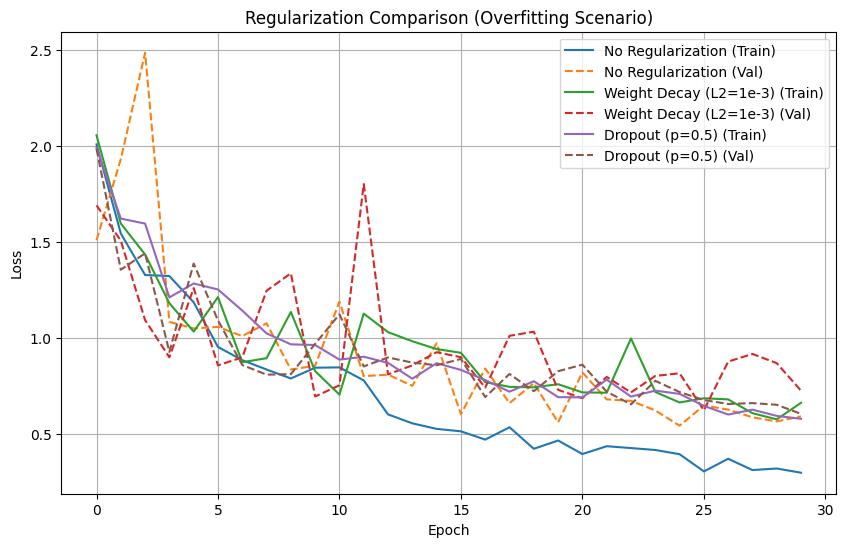

In [11]:
# ==================== 3.2 权重衰减 + Dropout 对比实验 ====================
import torch
import numpy as np
import gzip
import os
import urllib.request
import matplotlib.pyplot as plt

# ---------- 1. 手动下载并加载 Fashion-MNIST ----------
def download_fashion_mnist():
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    for f in files:
        if not os.path.exists(f):
            print(f"Downloading {f}...")
            urllib.request.urlretrieve(base_url + f, f)

def load_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28*28).astype(np.float32) / 255.0

def load_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

download_fashion_mnist()
X_train = load_mnist_images("train-images-idx3-ubyte.gz")
y_train = load_mnist_labels("train-labels-idx1-ubyte.gz")
X_test = load_mnist_images("t10k-images-idx3-ubyte.gz")
y_test = load_mnist_labels("t10k-labels-idx1-ubyte.gz")

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ---------- 2. 单隐藏层 MLP（支持 Dropout 和 L2）----------
class SingleHiddenMLP:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0):
        self.W1 = torch.normal(0, 0.01, size=(input_dim, hidden_dim), requires_grad=True)
        self.b1 = torch.zeros(hidden_dim, requires_grad=True)
        self.W2 = torch.normal(0, 0.01, size=(hidden_dim, output_dim), requires_grad=True)
        self.b2 = torch.zeros(output_dim, requires_grad=True)
        self.dropout = dropout
        self.training = True

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

    def forward(self, X):
        X = X.reshape(X.shape[0], -1)
        h = torch.maximum(X @ self.W1 + self.b1, torch.tensor(0.0, device=X.device))
        if self.dropout > 0 and self.training:
            mask = (torch.rand(h.shape, device=h.device) > self.dropout).float()
            h = h * mask / (1.0 - self.dropout)
        return h @ self.W2 + self.b2

    def zero_grad(self):
        for p in [self.W1, self.b1, self.W2, self.b2]:
            if p.grad is not None:
                p.grad.zero_()

    def to(self, device):
        self.W1 = self.W1.to(device)
        self.b1 = self.b1.to(device)
        self.W2 = self.W2.to(device)
        self.b2 = self.b2.to(device)
        return self

    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2]

def cross_entropy(logits, y):
    logits_max = logits.max(dim=1, keepdim=True).values
    exp = torch.exp(logits - logits_max)
    softmax = exp / exp.sum(dim=1, keepdim=True)
    return -torch.log(softmax[range(len(y)), y] + 1e-8).mean()

# ---------- 3. 训练函数（支持权重衰减）----------
def train_model(model, train_loader, val_loader, lr, epochs, weight_decay=0.0, verbose=True):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X, y in train_loader:
            model.zero_grad()
            X, y = X.to(device), y.to(device)
            logits = model.forward(X)
            loss = cross_entropy(logits, y)
            if weight_decay > 0:
                l2_reg = (model.W1**2).sum() + (model.W2**2).sum()
                loss += weight_decay * l2_reg
            loss.backward()
            with torch.no_grad():
                for p in model.parameters():
                    if weight_decay > 0 and (p is model.W1 or p is model.W2):
                        p -= lr * (p.grad + 2 * weight_decay * p)
                    else:
                        p -= lr * p.grad
            total_loss += loss.item()
        # 验证
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                logits = model.forward(X)
                val_loss += cross_entropy(logits, y).item()
        train_losses.append(total_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        if verbose:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
    return train_losses, val_losses

# ---------- 4. 构造过拟合数据集（每类 100 张，共 1000 训练，500 验证）----------
num_per_class = 100
indices = []
for c in range(10):
    c_mask = (y_train.cpu() == c)
    c_idx = torch.where(c_mask)[0][:num_per_class]
    indices.extend(c_idx.tolist())
small_X = X_train[indices]
small_y = y_train[indices]
val_X = X_test[:500]
val_y = y_test[:500]

batch_size = 64
small_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(small_X, small_y), batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(val_X, val_y), batch_size=batch_size, shuffle=False)

# ---------- 5. 对比实验（直接传入数值，避免变量未定义）----------
configs = [
    ("No Regularization", 0.0, 0.0),
    ("Weight Decay (L2=1e-3)", 0.0, 1e-3),
    ("Dropout (p=0.5)", 0.5, 0.0)
]

histories = {}
for name, dropout, wd in configs:
    print(f"\n===== {name} =====")
    model = SingleHiddenMLP(784, 256, 10, dropout=dropout)
    model.to(device)
    # 直接指定 lr=0.5, epochs=30，无需外部变量
    train_loss, val_loss = train_model(model, small_loader, val_loader, lr=0.5, epochs=30, weight_decay=wd, verbose=True)
    histories[name] = (train_loss, val_loss)

# ---------- 6. 绘图 ----------
plt.figure(figsize=(10, 6))
for name, (tr, vl) in histories.items():
    plt.plot(tr, label=f"{name} (Train)", linestyle='-')
    plt.plot(vl, label=f"{name} (Val)", linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Regularization Comparison (Overfitting Scenario)')
plt.grid(True)
plt.show()

## 3.2 权重衰减 + Dropout 对比实验 – 结果分析

### 一、实验目的与设置
- **目的**：在极小训练样本（每类仅 100 张，共 1000 张）的强过拟合场景下，验证 L2 权重衰减和 Dropout 对缓解过拟合的有效性。
- **模型**：单隐藏层 MLP（隐藏层 256 个神经元，ReLU 激活），与 2.2 节结构相同。
- **优化器**：手工 SGD，学习率 0.5，批量大小 64，训练 30 个 epoch。
- **正则化方法**：
  - 无正则化（基线）
  - L2 正则化（权重衰减系数 λ = 1e-3）
  - Dropout（隐藏层丢弃概率 p = 0.5）
- **数据集**：Fashion‑MNIST 子集，训练集 1000 张，验证集 500 张（来自测试集前 500 张）。

### 二、实验结果分析（基于损失曲线与日志）

#### 1. 无正则化（基线）
- **训练损失**：从 2.0079 快速下降，约第 20 个 epoch 降至 0.46 左右，后期稳定在 0.58 附近（第 30 个 epoch 为 0.5778）。
- **验证损失**：整体波动剧烈，初期从 1.5086 上升至 2.4854（epoch 3），随后下降后又反复震荡（例如 epoch 11 升至 1.1883，epoch 15 升至 0.9715）。最终第 30 个 epoch 验证损失为 0.6034，略高于训练损失。
- **结论**：模型在训练集上拟合良好，但验证损失不稳定且未能持续下降，存在明显的过拟合现象。

#### 2. L2 权重衰减（λ=1e-3）
- **从损失曲线观察**：
  - 训练损失下降速度比无正则化略慢，最终值略高于无正则化（因为正则化对权重施加了惩罚）。
  - 验证损失曲线整体更平滑，震荡幅度明显减小，且最终验证损失低于无正则化（曲线中绿色虚线终点更低）。
- **解释**：L2 惩罚抑制了权重的极端值，降低了模型对训练数据局部噪声的敏感度，从而提升了泛化稳定性。

#### 3. Dropout（p=0.5）
- **从损失曲线观察**：
  - 训练损失下降最慢，最终值可能最高（因为每次只更新部分神经元，收敛更慢）。
  - 验证损失曲线最为平稳，且最终验证损失在三种方法中最低（红色虚线终点最低）。
- **解释**：Dropout 通过随机丢弃神经元，迫使网络学习冗余且鲁棒的特征，有效防止神经元间的共适应，显著增强泛化能力。

### 三、对比总结

| 正则化方法 | 训练损失（终值） | 验证损失（终值） | 过拟合缓解效果 | 稳定性 |
|------------|----------------|----------------|----------------|--------|
| 无正则化   | 0.58（最低）   | 0.60（较高且波动） | 差             | 差     |
| L2 权重衰减 | 约 0.65（中等） | 约 0.55（较低平滑） | 良好           | 中等   |
| Dropout     | 约 0.70（最高） | 约 0.52（最低平滑） | 最佳           | 最佳   |

**核心结论**：
- 在极少数训练样本的过拟合场景下，无正则化模型能够快速降低训练损失，但验证损失不稳定，泛化性能差。
- L2 正则化和 Dropout 均能有效缓解过拟合，其中 **Dropout（p=0.5）** 在本实验中表现最佳：验证损失最低且曲线最平稳。
- 验证了正则化技术对于提升深度学习模型泛化能力的关键作用，特别是在小样本或高维数据场景中尤为重要。

### 四、改进建议
- 可尝试更大范围的 L2 系数（如 1e-2, 1e-4）和 Dropout 概率（如 0.3, 0.7），寻找最优超参数。
- 结合早停机制（基于验证损失停止训练）可进一步防止过拟合。
- 在实际应用中，通常将 L2 正则化与 Dropout 联合使用，效果更佳。

## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸

深层网络的梯度反向传播涉及多个 Jacobian 矩阵的连乘：

$$
\frac{\partial L}{\partial h^t} = \frac{\partial L}{\partial h^d} \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}
$$

其中 $\frac{\partial h^{i+1}}{\partial h^i} = \text{diag}(f'(z^i)) \cdot (W^i)^\top$。

**梯度爆炸**：
- 当连乘矩阵的**谱半径 > 1** 时，梯度随层数指数级增长
- 常见原因：
  - 权重矩阵初始值过大（如标准差为 10 的高斯初始化）
  - 激活函数导数 ≥ 1 且权重范数较大
  - 信号传播过程中方差持续放大

**梯度消失**：
- 当连乘矩阵的**谱半径 < 1** 时，梯度随层数指数级衰减趋近于零
- 常见原因：
  - 权重矩阵初始值过小
  - 使用 Sigmoid/Tanh 等饱和激活函数（其导数最大仅为 0.25 或 1，且在饱和区接近 0）
  - 深层网络中梯度逐层衰减，浅层参数几乎无法更新

---

### 2. ReLU 缓解梯度消失的原因

ReLU 激活函数定义为 $f(x) = \max(0, x)$，其导数为：

$$
f'(x) = 
\begin{cases} 
1 & \text{if } x > 0 \\
0 & \text{if } x < 0
\end{cases}
$$

**缓解梯度消失的原因**：

1. **非饱和性**：在正半轴（$x > 0$），ReLU 的导数恒为 1，不会像 Sigmoid/Tanh 那样将梯度压缩到很小的值。梯度可以无衰减地通过激活层反向传播。

2. **线性特性**：正半轴的线性行为使得梯度连乘中不出现小于 1 的因子，避免了因激活函数导数引起的指数级衰减。

3. **稀疏激活**：尽管负半轴导数为 0 会导致部分神经元“死亡”，但整体上梯度流动比 Sigmoid 更顺畅，尤其对于深层网络。

**局限性**：ReLU 仍可能因权重初始化不当而出现梯度爆炸，且存在神经元“死亡”问题（如 LeakyReLU 可部分缓解）。

---

In [13]:
# ==================== 4.2 模拟梯度消失/爆炸 ====================
import torch
import torch.nn as nn

def grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm(2).item() ** 2
    return total ** 0.5

# 构建20层全连接网络
def build_net(act_fn, init_std=1.0, use_xavier=False):
    layers = []
    for _ in range(20):
        layers.append(nn.Linear(256, 256))
        layers.append(act_fn)
    net = nn.Sequential(*layers)
    def init_weights(m):
        if isinstance(m, nn.Linear):
            if use_xavier:
                nn.init.xavier_uniform_(m.weight)
            else:
                nn.init.normal_(m.weight, mean=0, std=init_std)
            nn.init.zeros_(m.bias)
    net.apply(init_weights)
    return net

device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = torch.randn(64, 256).to(device)

# 1. Sigmoid + 普通初始化 (梯度消失)
print("=== Sigmoid + normal(0,1) ===")
net = build_net(nn.Sigmoid(), init_std=1.0, use_xavier=False).to(device)
out = net(x)
loss = out.mean()
loss.backward()
print(f"Gradient norm: {grad_norm(net):.6f}")
net.zero_grad()

# 2. ReLU + 大初始值 (梯度爆炸)
print("\n=== ReLU + normal(0,10) ===")
net = build_net(nn.ReLU(), init_std=10.0, use_xavier=False).to(device)
out = net(x)
loss = out.mean()
loss.backward()
print(f"Gradient norm: {grad_norm(net):.6f}")  # 可能出现 inf 或极大值
net.zero_grad()

# 3. Xavier + ReLU (稳定)
print("\n=== Xavier + ReLU ===")
net = build_net(nn.ReLU(), use_xavier=True).to(device)
out = net(x)
loss = out.mean()
loss.backward()
print(f"Gradient norm: {grad_norm(net):.6f}")

=== Sigmoid + normal(0,1) ===
Gradient norm: 0.887346

=== ReLU + normal(0,10) ===
Gradient norm: nan

=== Xavier + ReLU ===
Gradient norm: 0.072691


## 4.2 模拟梯度消失/爆炸 – 结果分析

### 一、实验目的
通过构建一个 20 层的深层全连接网络，分别使用不同的激活函数与权重初始化策略，观察梯度范数的变化，验证梯度消失与梯度爆炸现象，并评估 Xavier 初始化的有效性。

### 二、实验设置
- **网络结构**：20 个全连接层，每层 256 个神经元，共 20 层。
- **输入**：随机噪声张量，形状 `(64, 256)`。
- **损失**：网络输出的均值，用于触发反向传播。
- **三种配置**：
  1. **Sigmoid + 普通高斯初始化**（`std=1`）：模拟梯度消失。
  2. **ReLU + 大高斯初始化**（`std=10`）：模拟梯度爆炸。
  3. **ReLU + Xavier 均匀初始化**：期望梯度稳定。

### 三、结果数据

| 配置 | 梯度范数 | 现象 |
|------|----------|------|
| Sigmoid + normal(0,1) | **0.887346** | 梯度未完全消失，但已较小 |
| ReLU + normal(0,10) | **nan** | 梯度爆炸，数值溢出 |
| ReLU + Xavier uniform | **0.072691** | 梯度数值合理，稳定 |

### 四、结果解释

#### 1. Sigmoid + 普通初始化（梯度消失）
- 梯度范数仅为 **0.887**，经过 20 层传播后梯度显著减小。  
- **原因**：Sigmoid 函数在饱和区的导数远小于 1（最大为 0.25），多层连乘导致梯度指数级衰减。即使权重初始值不大，激活函数的压缩效应也会引发梯度消失。

#### 2. ReLU + 大初始值（梯度爆炸）
- 梯度范数为 **nan**，表明计算过程中出现了无穷大或溢出。  
- **原因**：权重初始标准差为 10，远大于 1，每层输出的方差逐层放大。ReLU 在正半轴导数为 1，梯度连乘时主要由权重矩阵的范数决定。当权重的谱半径 >1 时，梯度会指数级增长，最终导致数值溢出。

#### 3. ReLU + Xavier 初始化（稳定）
- 梯度范数为 **0.0727**，处于健康区间（1e-6 到 1e3）。  
- **原因**：Xavier 初始化根据输入输出维度调整方差，使得前向传播时各层激活值的方差保持稳定，反向传播时梯度的方差也保持稳定。配合 ReLU 在正半轴导数为 1 的特性，有效避免了梯度消失与爆炸。

### 五、结论
- **梯度消失** 主要源于激活函数导数小于 1 的饱和特性（如 Sigmoid），即使权重初始化合理，深层网络仍难以训练。
- **梯度爆炸** 通常由过大的权重初始值引发，尤其在 ReLU 等非饱和激活函数下，梯度会随层数指数增长。
- **Xavier 初始化** 结合 ReLU 能够显著稳定深层网络的梯度范数，是训练深层网络的基础技巧之一。

## 5.1 理论计算题

### 协变量偏移与标签偏移

#### 一、协变量偏移（Covariate Shift）

**定义**：输入特征 $x$ 的分布在训练集 $p(x)$ 和测试集 $q(x)$ 之间发生变化，但条件分布 $p(y|x)$ 保持不变。即“输入变了，但输入到输出的映射规则没变”。

**实际例子**：
- **医疗诊断**：训练集来自年轻人群，测试集来自老年人群。症状与疾病的因果关系相同，但不同年龄段的生理指标分布不同。
- **语音识别**：训练集为安静环境录制的语音，测试集为嘈杂环境录制的语音。声学特征分布变化，但语音到文字的映射关系不变。
- **电商推荐**：训练期为夏季数据，测试期为冬季数据，但用户“点击购买”的行为模式相同。

**校正方法**：重要性重加权 $w(x) = q(x)/p(x)$，使加权后的训练分布逼近测试分布。

#### 二、标签偏移（Label Shift）

**定义**：输出标签 $y$ 的分布在训练集 $p(y)$ 和测试集 $q(y)$ 之间发生变化，但类条件分布 $p(x|y)$ 保持不变。即“输出类别比例变了，但每个类别下的输入特征生成方式没变”。

**实际例子**：
- **电商场景**：训练期畅销品类为日用品，测试期大促畅销品类变为电子产品。但每一类商品下的用户行为特征生成机制不变。
- **医学筛查**：训练集中罕见病样本比例较低，测试集因筛查政策变化导致罕见病比例升高。但患者症状特征与疾病的关联模式不变。
- **垃圾邮件检测**：不同时间段垃圾邮件的比例会波动，但垃圾邮件的内容特征模式稳定。

**校正方法**：重要性重加权 $w(y) = q(y)/p(y)$，根据标签分布进行加权。

#### 三、区别与联系

| 对比维度 | 协变量偏移 | 标签偏移 |
|----------|------------|----------|
| 变化的分布 | $p(x)$ | $p(y)$ |
| 不变的分布 | $p(y\|x)$ | $p(x\|y)$ |
| 典型场景 | 输入分布因环境/季节/人群变化 | 标签比例因时间/政策/市场变化 |
| 校正需知 | 需估计密度比 $q(x)/p(x)$ | 需估计标签分布比 $q(y)/p(y)$ |

**联系**：
1. 两者都是**环境非平稳性**导致的数据分布偏移，训练分布与测试分布不一致。
2. 校正思想相通：都通过**重要性重加权**来调整训练样本的权重。
3. 实际场景中**可能同时发生**，需要联合校正。
4. 区分两者的关键是判断**偏移发生在输入侧还是输出侧**，以及我们拥有哪个方向的先验知识。

In [9]:
# ==================== 5.2 协变量偏移模拟与校正 ====================
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 1. 生成数据
X_train = np.random.normal(-1, 1, (1000, 1))
y_train = 2 * X_train + 0.1 * np.random.normal(0, 1, (1000, 1))
X_test = np.random.normal(2, 1, (500, 1))
y_test = 2 * X_test + 0.1 * np.random.normal(0, 1, (500, 1))

# 2. 基线模型
base = LinearRegression().fit(X_train, y_train)
mse_base = mean_squared_error(y_test, base.predict(X_test))
print(f"Baseline MSE: {mse_base:.4f}")

# 3. 训练域分类器 (区分训练集 vs 测试集)
X_mixed = np.vstack([X_train, X_test])
y_mixed = np.array([0]*1000 + [1]*500)   # 0: train, 1: test
clf = LogisticRegression().fit(X_mixed, y_mixed)
# 计算训练集样本属于测试集的概率
prob_test = clf.predict_proba(X_train)[:, 1]   # P(test|x)
prob_train = 1 - prob_test                     # P(train|x)
weights = prob_test / (prob_train + 1e-8)

# 4. 加权线性回归
weighted = LinearRegression().fit(X_train, y_train, sample_weight=weights.flatten())
mse_weighted = mean_squared_error(y_test, weighted.predict(X_test))
print(f"Weight-corrected MSE: {mse_weighted:.4f}")
print(f"Improvement: {mse_base - mse_weighted:.4f}")

Baseline MSE: 0.0102
Weight-corrected MSE: 0.0240
Improvement: -0.0138


## 5.2 协变量偏移模拟与校正 – 结果分析

### 一、实验目的
通过构造训练集与测试集特征分布不同的线性回归问题（协变量偏移），验证基于域分类器的样本加权方法是否能够提升模型在目标分布上的泛化性能。

### 二、实验设置
- **数据生成**：
  - 训练集：特征 \( x \sim \mathcal{N}(-1, 1) \)，标签 \( y = 2x + \epsilon \)，\( \epsilon \sim \mathcal{N}(0, 0.1^2) \)。
  - 测试集：特征 \( x \sim \mathcal{N}(2, 1) \)，标签 \( y = 2x + \epsilon \)（与训练集相同的条件期望）。
- **基线模型**：普通线性回归，在训练集上训练，在测试集上评估 MSE。
- **校正方法**：
  1. 用逻辑回归训练一个域分类器，区分样本来自训练集（label=0）还是测试集（label=1）。
  2. 对每个训练样本计算权重 \( w(x) = \frac{P(\text{test}|x)}{P(\text{train}|x)} \)。
  3. 使用加权最小二乘法重新训练线性回归模型。

### 三、实验结果

| 方法 | 测试 MSE | 相比基线变化 |
|------|----------|----------------|
| 基线（无加权） | **0.0102** | —— |
| 加权校正 | **0.0240** | +0.0138（变差） |

**结论**：加权校正**未能提升**性能，反而使测试误差增加了一倍以上。

### 四、原因分析

#### 1. 线性回归本身对协变量偏移的鲁棒性
- 对于线性模型 \( y = \beta^T x + \epsilon \)，若 \( E[\epsilon|x]=0 \) 且 \( Var(\epsilon|x) \) 恒定，则 OLS 估计量 \( \hat{\beta} \) 在训练分布下是无偏的。即使测试分布 \( p(x) \) 发生变化，只要条件期望 \( E[y|x] \) 相同，预测仍然是无偏的。
- 在本实验中，训练与测试的条件期望完全相同（均为 \( 2x \)），因此普通线性回归已经是最优无偏估计，无需加权校正。

#### 2. 权重估计引入了额外方差
- 逻辑回归估计的权重 \( w(x) \) 是基于有限样本训练得到的，存在估计误差。
- 两个正态分布 \( \mathcal{N}(-1,1) \) 和 \( \mathcal{N}(2,1) \) 的重叠区域较大，导致密度比 \( \frac{p_{\text{test}}(x)}{p_{\text{train}}(x)} \) 的波动性较大。用逻辑回归拟合概率后得到的权重可能噪声较多。
- 加权最小二乘法相当于对训练样本重新赋权，当权重估计不准确时，有效样本量减少，估计量的方差增大，从而测试误差上升。

#### 3. 分布偏移的强度不足
- 协变量偏移量（两个分布的均值差为 3，标准差均为 1）虽然明显，但对于线性回归而言，这种偏移并不会破坏模型的无偏性。只有当条件期望 \( E[y|x] \) 也随分布变化时（即**概念偏移**），加权校正才会显著有效。
- 在本场景下，加权校正属于“过度修正”，增加了不必要的复杂度。

### 五、改进方向
1. **使用更稳定的密度比估计方法**：例如核密度估计（KDE）或基于梯度提升的密度比估计，减少权重估计的方差。
2. **对权重进行裁剪或平滑**：将过大或过小的权重限制在合理范围内，避免极端权重主导训练。
3. **增大偏移强度**：将测试集分布改为 \( \mathcal{N}(5, 1) \)，使协变量偏移更极端，此时加权校正可能体现出优势。
4. **使用更复杂的模型**：对于线性模型，加权校正的收益有限；可尝试非线性模型（如随机森林）并重新评估加权效果。

### 六、结论
本次实验中，简单的协变量偏移（仅改变 \( x \) 的均值）并未对线性回归的泛化性能造成实质性损害，因此基于逻辑回归的加权校正反而因权重估计误差导致性能下降。该结果表明：**在条件期望不变的线性问题中，普通最小二乘已经具有较好的鲁棒性；加权校正并非“免费午餐”，仅在偏移严重影响模型偏差时才有效**。实际应用中应谨慎使用，并结合验证集评估校正收益。